# DES Y6 covariance forecast

Compute Gaussian (G), super-sample (SSC), connected non-Gaussian (cNG) and total covariance for **six lens bins, four source bins and 26 angular bins**: a **1,300 × 1,300** matrix.

Use this notebook to inspect intermediate quantities. For production or HPC work, run `covariance/compute_covariance.py` with `EXAMPLE_EVALUATE_COVARIANCE.yaml`; its direct bindings avoid the notebook wrappers' array conversions. Both routes call the same C kernels.

This is an **analogous forecast**, not a released DES Y6 likelihood. The active dataset uses dummy data and a unit covariance. The separate `DESY6.cov` has 1,690 entries and no verified mapping to this layout, so it is not compared here. See [survey inputs and model limits](covariance/README.md).

Activate Cocoa and set `OMP_NUM_THREADS` before opening Jupyter. Restart the kernel after recompiling the interface.

In [1]:
import os
from pathlib import Path
import sys

# BLAS stays serial; the compiled CosmoLike loops own the OpenMP workers.
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
root = Path(os.environ["ROOTDIR"])
project = root/"projects/des_y6"
sys.path.insert(0, str(root/"external_modules/code/cosmolike_core"))
sys.path.insert(0, str(root/"external_modules/code/CAMB"))
sys.path.insert(0, str(project/"interface"))
sys.path.insert(0, str(project/"covariance"))

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from threadpoolctl import threadpool_limits
import cosmolike_des_y6_interface as ci
import des_y6_covariance as survey
from cosmolike_notebook_utils import covariance as cov
from cosmolike_notebook_utils import plot_covariances as pcov
from cosmolike_notebook_utils.covariance.forecast import save_forecast

blas_limit = threadpool_limits(limits=1, user_api="blas")
threads = int(os.environ["OMP_NUM_THREADS"])
ci.set_omp_threads(n=threads)
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams.update({
    "xtick.bottom": True,
    "xtick.top": False,
    "ytick.right": False,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "axes.labelsize": "medium",
    "axes.grid": True,
    "grid.linewidth": 0.0,
    "grid.alpha": 0.18,
    "grid.color": "lightgray",
    "legend.labelspacing": 0.77,
    "savefig.bbox": "tight",
    "savefig.format": "pdf",
})


## Choose the forecast

Published catalogue values set the densities, per-component shape dispersions and area; normalized n(z) columns set the radial shapes. The forecast uses the example cosmology with **massless neutrinos**, linear galaxy bias, a spherical-cap footprint and no magnification or RSD.

Gaussian gg/gs spectra include the non-Limber correction; shear-shear remains Limber. Set `ia` to `NLA` or `TATT` and specify amplitudes to explore Gaussian IA. SSC and cNG retain the zero-IA Limber matter model.

`accuracy_boost` refines interpolation tables; `integration_accuracy` selects quadrature rules independently. The default covariance power preparation has 11,993 wavenumbers and does not change ordinary likelihood power tables.

In [2]:
settings = survey.configuration(
    accuracy_boost=1,
    integration_accuracy=0,
    gaussian={"nonlimber": True, "ia": "none"},
)
for key in (
    "area_deg2",
    "lens_density_arcmin2",
    "source_density_arcmin2",
    "sigma_e_component",
    "bias",
    "cosmology",
    "accuracy_parameters",
):
    print(key, settings[key])
camb_tables = survey.initialize(interface=ci, settings=settings)
ci.set_omp_threads(n=threads)


def progress(stage, elapsed):
    """Print elapsed seconds at each completed covariance construction stage."""
    print(f"{elapsed:8.2f} s  {stage}")


area_deg2 4031.04
lens_density_arcmin2 [0.128, 0.092, 0.097, 0.123, 0.096, 0.097]
source_density_arcmin2 [2.05, 2.1, 2.14, 2.32]
sigma_e_component [0.265, 0.287, 0.282, 0.347]
bias [1.54, 1.81, 1.85, 1.76, 1.93, 1.9]
cosmology {'omegam': 0.319, 'omegab': 0.049, 'H0': 67.0, 'ns': 0.96, 'As_1e9': 2.1, 'w': -1.0, 'w0pwa': -1.0, 'mnu': 0.0, 'AccuracyBoost': 1.0, 'CLAccuracyBoost': 1.0, 'CAMBAccuracyBoost': 1.0, 'kmax': 20.0, 'k_per_logint': 20, 'non_linear_emul': 2, 'lens_potential_accuracy': 1.0, 'halofit_version': 'takahashi'}
accuracy_parameters {'non_gaussian_accuracyboost': 1, 'window_accuracyboost': 1, 'core_accuracyboost': 1, 'power_accuracyboost': 8, 'nonlimber_accuracyboost': 1, 'ell_max': 100000, 'mask_ell_max': 32768, 'ng_ell_intervals': 127, 'response_step': 5e-05, 'nonlimber_lmax': 1000, 'integration_accuracy': 0}


## See the 1h, 2h, 3h and 4h matter trispectra

The **trispectrum** describes the connected four-point correlation of the
matter density in Fourier space. Its four density factors can live in one,
two, three or four halos. The halo model separates their contributions:

| Term | Where the four density factors live |
| --- | --- |
| 1h | All four in one halo. |
| 2h | Two halos, partitioned as 1+3 or 2+2 factors. Both partitions enter. |
| 3h | Three halos, partitioned as 2+1+1 factors. |
| 4h | Four different halos. |

For power-spectrum covariance the wavevectors form
$\mathbf{k},-\mathbf{k},\mathbf{q},-\mathbf{q}$.
The helper averages over the angle between $\mathbf{k}$ and $\mathbf{q}$
in the transverse plane.
Below, choose one redshift and plot the diagonal $q=k$:
$\overline{T}=T_{1h}+T_{2h}^{(1+3)}+T_{2h}^{(2+2)}+T_{3h}+T_{4h}$.
This is a **matter trispectrum before survey projection**, not a diagonal
of the project's covariance matrix. SSC and Gaussian covariance are separate.

The example uses the initialized cosmology, mass panels and integration
level above. Its 65 wavenumbers sample the plot; they do not change the
integration rule. Internally CosmoLike measures lengths in $c/H_0$.
Convert the input $k$ from $h/\mathrm{Mpc}$ and the output trispectrum
back to $(\mathrm{Mpc}/h)^9$ for the figure.

`halo_terms` retains every unordered $(k,q)$ pair, including off-diagonal
pairs. `T2h_13` and `T2h_22` remain separate arrays; only the plotted 2h
curve combines them. The signed logarithmic y axis preserves negative
contributions and is linear within $|\overline{T}|<1\,(\mathrm{Mpc}/h)^9$.
Changing `halo_redshift` below explores another epoch without rerunning CAMB.


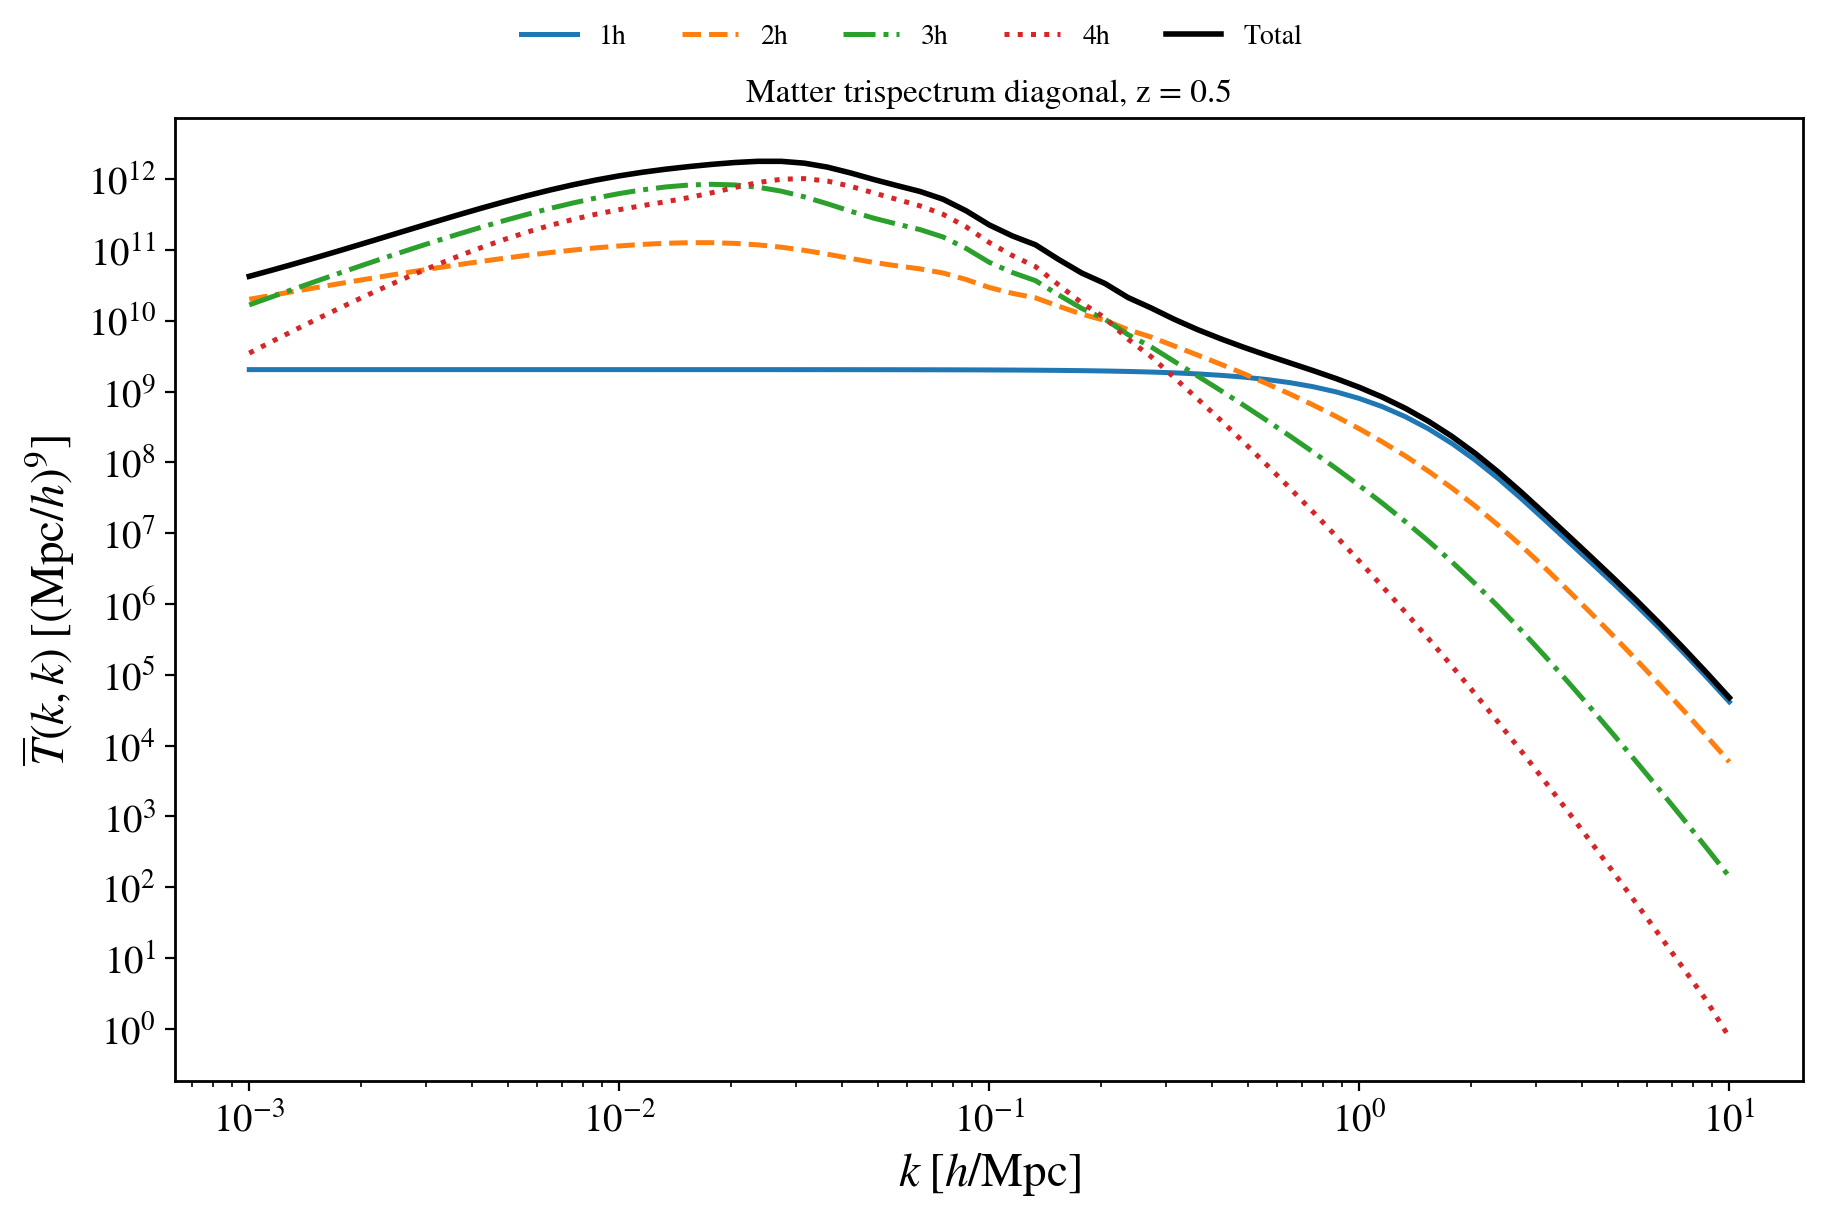

In [3]:
halo_redshift = 0.5
halo_scale_factor = 1.0/(1.0+halo_redshift)
k_hmpc = np.geomspace(start=1.e-3, stop=10.0, num=65)

# c/H0 is 2997.92458 Mpc/h: the factor h is already in the length unit.
# A trispectrum has nine powers of length, whereas power has three.
cover_h0_mpc_over_h = 2997.92458
k_core = k_hmpc*cover_h0_mpc_over_h
halo_terms = cov.halo_trispectrum(
    interface=ci,
    a=halo_scale_factor,
    k=k_core,
    lnm_edges=settings["lnm_edges"],
    accuracy_boost=settings["accuracy_boost"],
    mnu=settings["cosmology"]["mnu"],
    integration_accuracy=settings["integration_accuracy"],
)
terms_mpc_over_h9 = halo_terms["terms"]*cover_h0_mpc_over_h**9

# The five rows distinguish the two possible two-halo partitions.
# Every row uses the same triangular ordering of wavenumber pairs.
T1h = terms_mpc_over_h9[0]
T2h_13 = terms_mpc_over_h9[1]
T2h_22 = terms_mpc_over_h9[2]
T3h = terms_mpc_over_h9[3]
T4h = terms_mpc_over_h9[4]
T2h = T2h_13+T2h_22

# Equal pair indices select q=k, in the order of the original k grid.
diagonal_pairs = halo_terms["first"] == halo_terms["second"]
halo_diagonal = {
    "1h": T1h[diagonal_pairs],
    "2h": T2h[diagonal_pairs],
    "3h": T3h[diagonal_pairs],
    "4h": T4h[diagonal_pairs],
}
pcov.plot_trispectrum_terms(
    k_hmpc=k_hmpc,
    components=halo_diagonal,
    redshift=halo_redshift,
)


## Compute the complete matrix

The order is ξ+, ξ−, γt, w. Angular bins are consecutive within each tomographic pair. All lens-source pairs are included, with lens-auto clustering only. Internal cross spectra still enter the Gaussian contractions.

`space="fourier"` produces an illustrative 600-entry matrix in 15 multipole bands. Its ordering differs from the real-space likelihood, so the real-space mask must not be applied to it.

In [4]:
forecast = survey.compute(
    interface=ci,
    settings=settings,
    space="real",
    progress=progress,
)
print("Full covariance shape:", forecast["total"].shape)
block_sizes = [260, 260, 624, 156]
block_labels = [r"$\xi_+$", r"$\xi_-$", r"$\gamma_t$", r"$w$"]


    1.39 s  all_pairs_gaussian_spectra


    2.93 s  angular_and_mask_geometry


    5.55 s  gaussian_blocks
    5.73 s  observable_signal


    6.33 s  Matter shell 1/672


   14.07 s  Matter shell 33/672


...

  143.70 s  Matter shell 577/672


  151.29 s  Matter shell 609/672


  158.87 s  Matter shell 641/672


  166.16 s  shared_halo_response_and_trispectrum


  166.39 s  ssc_and_connected_projection
  166.39 s  total
Full covariance shape: (1300, 1300)


## Inspect every component

The correlation plot normalizes each total entry by the product of its diagonal rms values. Component maps retain signed cross terms and use the total diagonal for normalization. No eigenvalues are clipped or repaired.

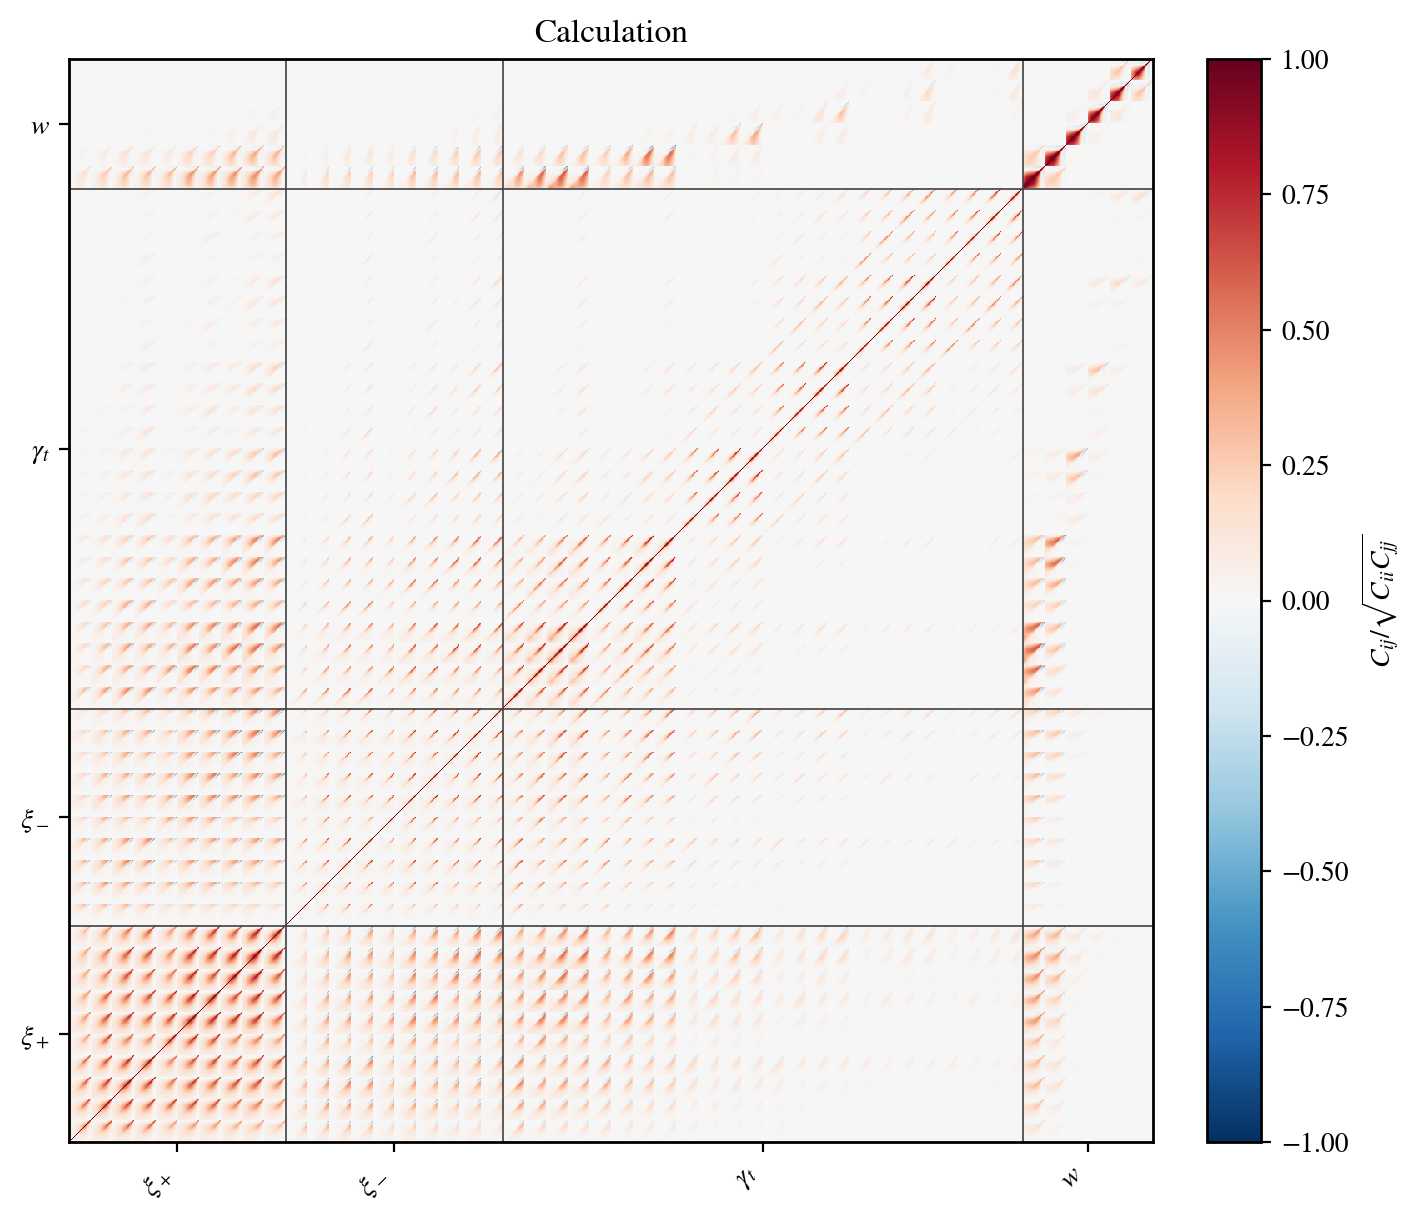

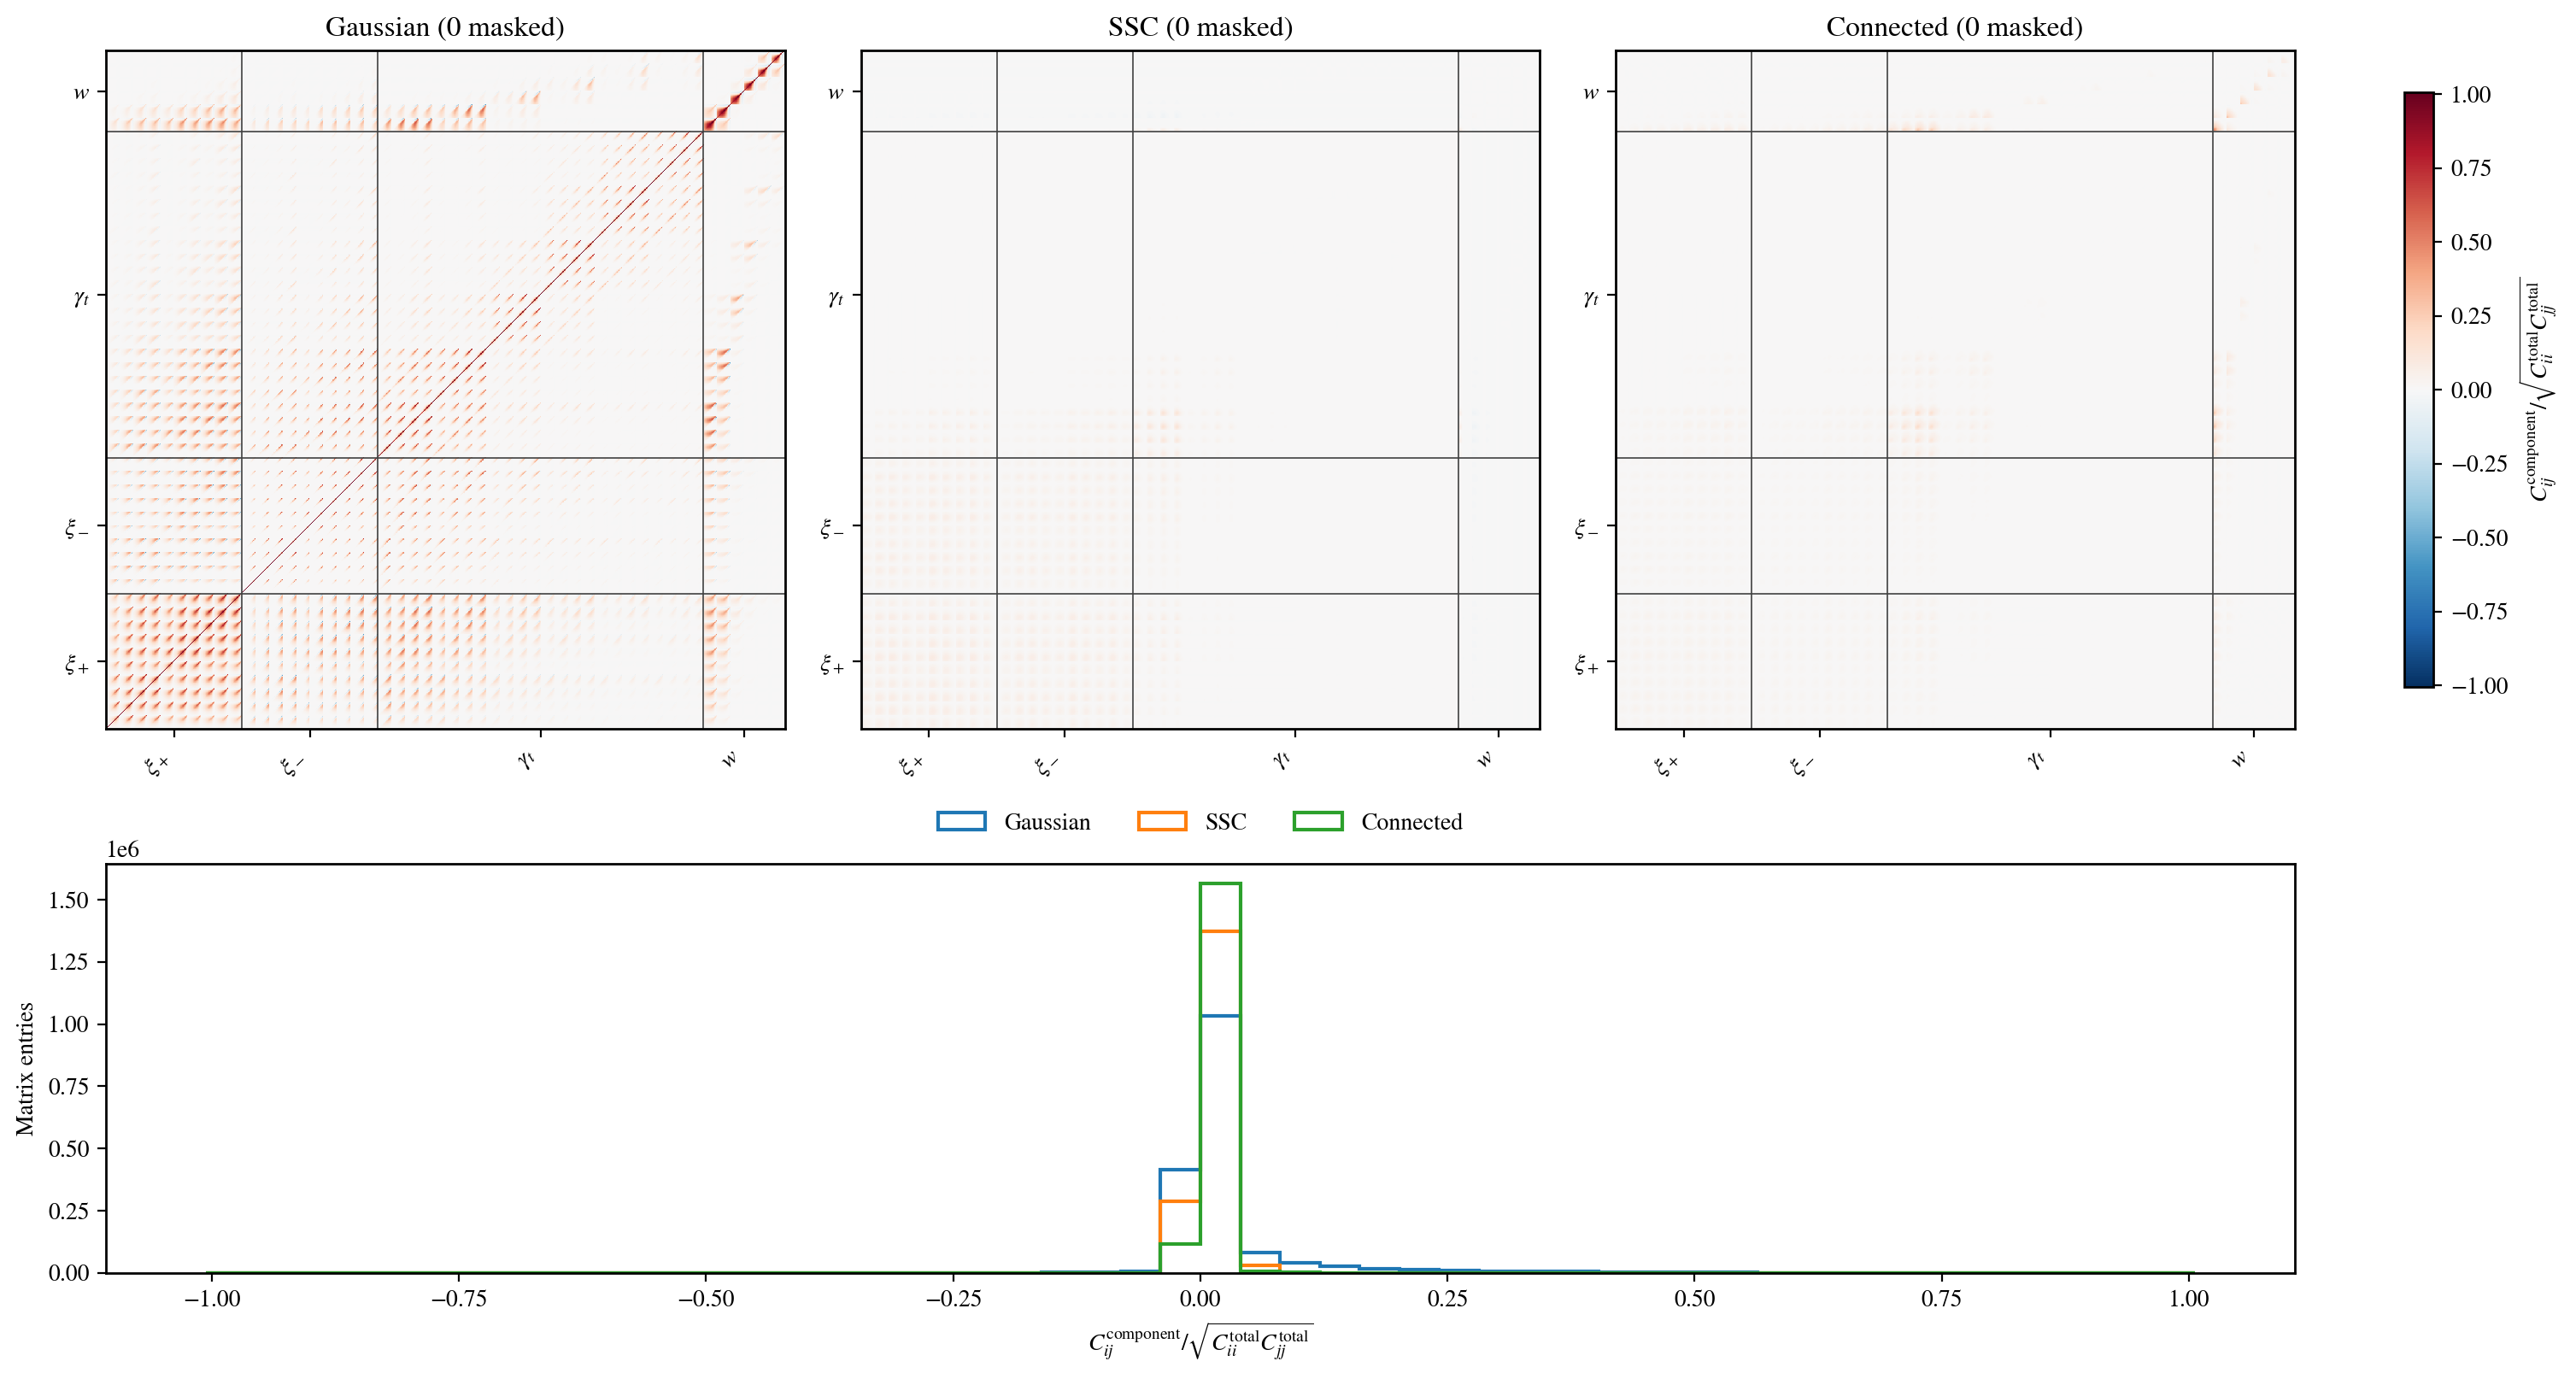

gaussian finite: True symmetric: True
ssc finite: True symmetric: True
cng finite: True symmetric: True
total finite: True symmetric: True


Full total positive definite: True
Minimum correlation eigenvalue: 0.007590995072663342


In [5]:
pcov.plot_correlation(
    covariance=forecast["total"],
    block_sizes=block_sizes,
    block_labels=block_labels,
)
pcov.plot_covariance_components(
    total=forecast["total"],
    components={
        "Gaussian": forecast["gaussian"],
        "SSC": forecast["ssc"],
        "Connected": forecast["cng"],
    },
    block_sizes=block_sizes,
    block_labels=block_labels,
    normalization="diagonal",
)
for name in ("gaussian", "ssc", "cng", "total"):
    matrix = forecast[name]
    print(name, "finite:", np.all(np.isfinite(matrix)),
          "symmetric:", np.array_equal(matrix, matrix.T))
modes = cov.covariance_modes(matrix=forecast["total"])
print("Full total positive definite:", modes["positive_definite"])
print("Minimum correlation eigenvalue:", modes["correlation_eigenvalues"][0])


## Inspect the supplied scale selection

`DESY6.mask` retains 541 entries in this layout. Applying it is an optional selection of the forecast; it does not make this the survey likelihood covariance. The active dummy dataset uses `ones.mask`.

A selection must act on **both matrix axes**. Original indices are saved so retained entries can be traced to the uncut ordering.

In [6]:
mask_table = np.loadtxt(fname=project/"data/DESY6.mask")
assert np.array_equal(mask_table[:, 0], np.arange(1300))
assert np.all(np.isin(mask_table[:, 1], [0, 1]))
indices = np.flatnonzero(mask_table[:, 1])
# np.ix_ selects every retained row crossed with every retained column.
selection = np.ix_(indices, indices)
selected = {"indices": indices}
for name in ("gaussian", "ssc", "cng", "total"):
    selected[name] = forecast[name][selection]
print("Retained entries:", len(indices))
selected_modes = cov.covariance_modes(matrix=selected["total"])
print("Selected total positive definite:", selected_modes["positive_definite"])
print("Minimum correlation eigenvalue:",
      selected_modes["correlation_eigenvalues"][0])


Retained entries: 541
Selected total positive definite: True
Minimum correlation eigenvalue: 0.007838083728618972


## Save components and inputs

The forecast archive preserves G, SSC, cNG, total, coordinates, signal, row ordering and resolved settings. Additional archives hold the explicitly selected matrices and prepared CAMB arrays. Files are written under `covariance/`, where NPZ outputs are ignored by Git. Nothing in `data/` is overwritten.

In [7]:
save_forecast(
    result=forecast,
    filename=project/"covariance/forecast_real.npz",
)
np.savez(file=project/"covariance/forecast_selected.npz", **selected)
np.savez(file=project/"covariance/forecast_camb.npz", **camb_tables)
print("Saved full and selected matrices and CAMB inputs under covariance/.")


Saved full and selected matrices and CAMB inputs under covariance/.
